--- LOF OPTIMIZAT: 100K SAMPLES & 64GB RAM CONFIG ---
Încărcare date din fișierele .pt...
Se extrage un eșantion de 100000 rânduri pentru antrenare...
Antrenare în curs...
Antrenare finalizată în 170.51 secunde.
Model salvat în: D:\disertatie\modele_2018\LOF\model_lof_2018_100k_cpu.pkl
Generare rezultate...

              precision    recall  f1-score   support

      Normal       1.00      0.75      0.86      7633
    Anomalie       0.92      1.00      0.96     22367

    accuracy                           0.94     30000
   macro avg       0.96      0.87      0.91     30000
weighted avg       0.94      0.94      0.93     30000

AUC: 0.9529
Graficele au fost salvate în: D:\disertatie\rezultate_2018\LOF


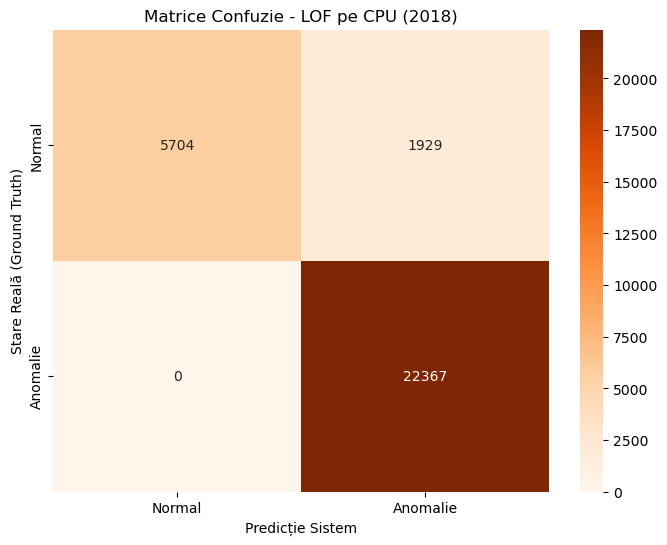

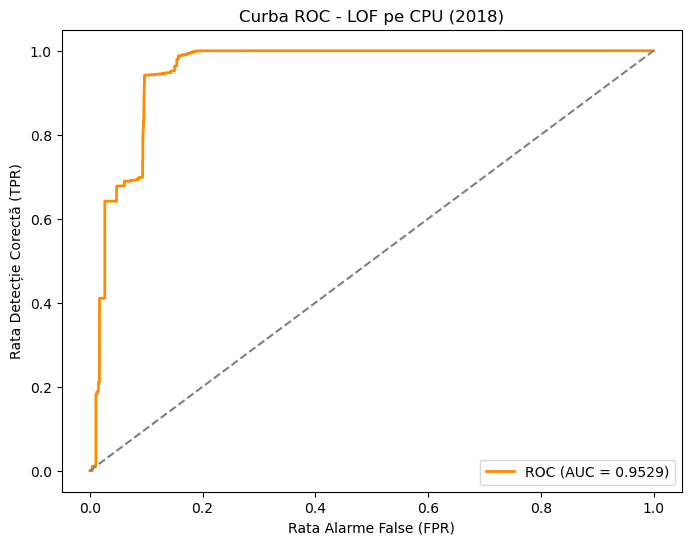

In [1]:
import torch
import numpy as np
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

data_path = r'D:\disertatie\preprocesare_anomalii_2018'
model_save_path = r'D:\disertatie\modele_2018\LOF'
rezultate_path = r'D:\disertatie\rezultate_2018\LOF'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- LOF OPTIMIZAT: 100K SAMPLES & 64GB RAM CONFIG ---")

print("Încărcare date din fișierele .pt...")
X_train_full = torch.load(os.path.join(data_path, 'X_train_2018.pt')).numpy()
X_test_full = torch.load(os.path.join(data_path, 'X_test_2018.pt')).numpy()
y_test_full = torch.load(os.path.join(data_path, 'y_test_2018.pt')).numpy()

np.random.seed(42)
n_train = 100000
n_test = 30000

print(f"Se extrage un eșantion de {n_train} rânduri pentru antrenare...")
idx_train = np.random.choice(len(X_train_full), n_train, replace=False)
X_train = X_train_full[idx_train]

idx_test = np.random.choice(len(X_test_full), n_test, replace=False)
X_test = X_test_full[idx_test]
y_test = y_test_full[idx_test]

model = LocalOutlierFactor(
    n_neighbors=50, 
    contamination=0.25, 
    novelty=True, 
    n_jobs=8, 
    leaf_size=200, 
    algorithm='ball_tree'
)

start_time = time.time()
print("Antrenare în curs...")
model.fit(X_train)
train_time = time.time() - start_time
print(f"Antrenare finalizată în {train_time:.2f} secunde.")

model_file = os.path.join(model_save_path, 'model_lof_2018_100k_cpu.pkl')
joblib.dump(model, model_file)
print(f"Model salvat în: {model_file}")

print("Generare rezultate...")
y_pred_raw = model.predict(X_test)
y_pred = [1 if x == -1 else 0 for x in y_pred_raw]


decision_scores = model.score_samples(X_test)
y_scores = -decision_scores 

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie'])
print("\n" + report)
print(f"AUC: {roc_auc:.4f}")

with open(os.path.join(rezultate_path, 'raport_lof_100k_cpu.txt'), 'w') as f:
    f.write(f"REZULTATE LOF (SAMPLING 100K)\nAUC: {roc_auc:.4f}\nTimp: {train_time:.2f}s\n\n{report}")


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.title('Matrice Confuzie - LOF pe CPU (2018)')
plt.savefig(os.path.join(rezultate_path, 'matrice_lof_100k_cpu.png'))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Curba ROC - LOF pe CPU (2018)')
plt.legend(loc="lower right")
plt.savefig(os.path.join(rezultate_path, 'roc_lof_100k_cpu.png'))

print(f"Graficele au fost salvate în: {rezultate_path}")